In [1]:
# Plot decadal total global mortality

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import get_scenario_config

In [2]:
def load_global_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [3]:
def create_decade_average(da):
    # Assume your DataArray is called da with dims (ensemble, year, samples)

    # Extract years
    years = da.year.values

    # Define decades backwards from the last year
    end_year = years[-1]
    start_year = years[0]

    # Create bins of 10 years backwards
    bins = []
    while end_year >= start_year:
        bin_start = max(start_year, end_year - 9)
        bins.append((bin_start, end_year))
        end_year = bin_start - 1

    # Reverse to keep chronological order (optional)
    bins = bins[::-1]

    print("Decade bins:", bins)
    # e.g. [(2035, 2044), (2045, 2054), (2055, 2064), (2065, 2074), (2075, 2083)]

    # Assign each year to a decade label
    decade_labels = []
    for yr in years:
        for i, (start, end) in enumerate(bins):
            if start <= yr <= end:
                decade_labels.append(f"{start}-{end}")
                break

    # Convert to DataArray for grouping
    decade_da = xr.DataArray(decade_labels, coords={"year": years}, dims="year")

    # Group by decade and take mean
    decadal_means = da.groupby(decade_da).mean(dim="year")

    return decadal_means

In [4]:
def plot_2_box_plot(ds1, ds2, model, scenario, SAVE_DIR):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Dataset A: SSP245, dataset B: G6-1.5K
    decade_meanA = create_decade_average(ds1)
    decade_meanB = create_decade_average(ds2)

    # x positions for each group
    x_A = np.arange(len(decade_meanA.group)) * 2.0  # space out decades
    x_B = x_A + 0.8  # offset for dataset B

    # Plot dataset A
    plt.violinplot(decade_meanA)

    # Plot dataset B
    plt.violinplot(decade_meanB)

    # Custom x-ticks: center between the two
    xticks = (x_A + x_B) / 2
    ax.set_xticks(xticks)
    ax.set_xticklabels(decade_meanA.group)
    ax.set_ylim(bottom=0)

    ax.set_ylabel("Global Mortality")
    ax.legend([plt.Line2D([0], [0], color="skyblue", lw=4),
               plt.Line2D([0], [0], color="lightcoral", lw=4)],
              ["SSP245", "G6-1.5K"])

    plt.title("Global Mortality")

    out_file = f"Global_mortality_boxplot_{model}_{scenario}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    #plt.savefig(out_path)
    return

In [6]:
# === Plotting both scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "UKESM1"
n_samples = 300

scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)
da1 = load_global_mortality_ensemble_members(model, scenario, config, n_samples)
da_decade1 = create_decade_average(da1)

scenario = "SSP245_G6"

config = get_scenario_config(model, scenario)
da2 = load_global_mortality_ensemble_members(model, scenario, config, n_samples)
da_decade2 = create_decade_average(da2.sel(year=da1.year))

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Decade bins: [(2035, 2043), (2044, 2053), (2054, 2063), (2064, 2073), (2074, 2083)]
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Decade bins: [(2035, 2043), (2044, 2053), (2054, 2063), (2064, 2073), (2074, 2083)]


In [7]:
# Convert to list of arrays (one per decade)
data1 = [da_decade1.sel(group=dec).values.ravel() for dec in da_decade1.group.values]
data2 = [da_decade2.sel(group=dec).values.ravel() for dec in da_decade2.group.values]

decades = da_decade1.group.values

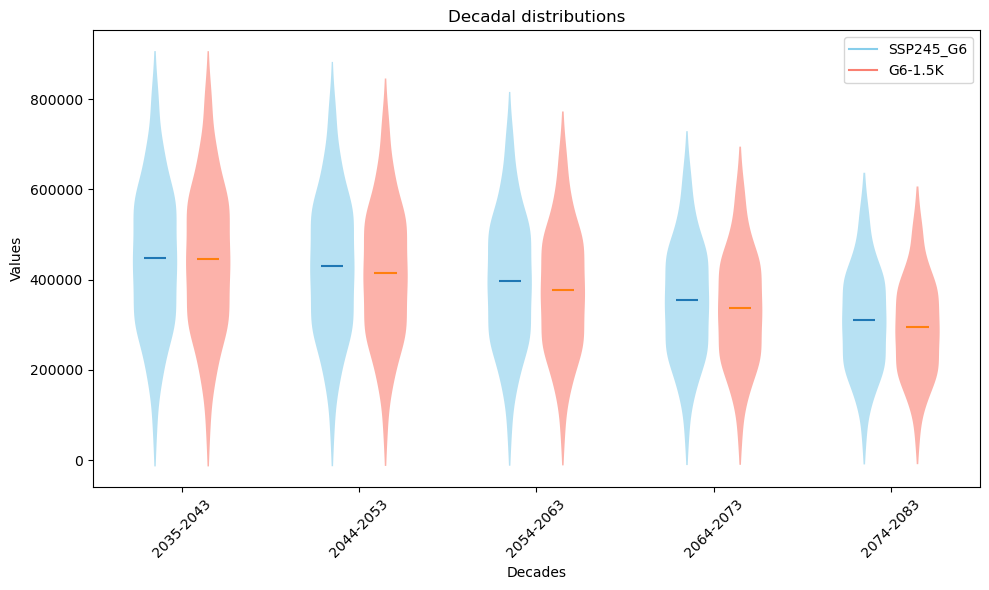

In [8]:
fig, ax = plt.subplots(figsize=(10,6))

positions1 = np.arange(len(decades)) - 0.15
positions2 = np.arange(len(decades)) + 0.15

vp1 = ax.violinplot(data2, positions=positions1, widths=0.25, showmeans=True, showextrema=False)
vp2 = ax.violinplot(data1, positions=positions2, widths=0.25, showmeans=True, showextrema=False)

# Style
for vp in vp1['bodies']:
    vp.set_facecolor("skyblue")
    vp.set_alpha(0.6)
for vp in vp2['bodies']:
    vp.set_facecolor("salmon")
    vp.set_alpha(0.6)

ax.set_xticks(np.arange(len(decades)))
ax.set_xticklabels(decades, rotation=45)
ax.set_ylabel("Values")
ax.set_xlabel("Decades")
ax.set_title("Decadal distributions")

# Add legend proxy
ax.plot([], [], color="skyblue", label="SSP245_G6")
ax.plot([], [], color="salmon", label="G6-1.5K")
ax.legend()

plt.tight_layout()
plt.show()

Decade bins: [(2035, 2043), (2044, 2053), (2054, 2063), (2064, 2073), (2074, 2083)]


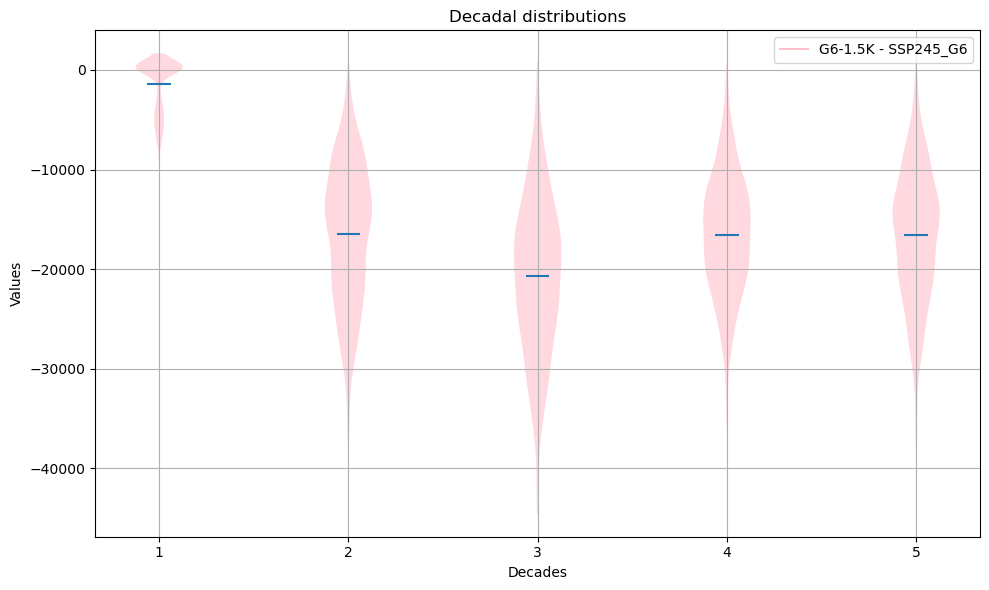

In [9]:
da = da1 - da2
da_decade = create_decade_average(da)
data = [da_decade.sel(group=dec).values.ravel() for dec in da_decade.group.values]

fig, ax = plt.subplots(figsize=(10,6))

vp1 = ax.violinplot(data, widths=0.25, showmeans=True, showextrema=False)

# Style
for vp in vp1['bodies']:
    vp.set_facecolor("pink")
    vp.set_alpha(0.6)

#ax.set_xticks(np.arange(len(decades)))
#ax.set_xticklabels(decades, rotation=45)
ax.set_ylabel("Values")
ax.set_xlabel("Decades")
ax.set_title("Decadal distributions")

# Add legend proxy
ax.plot([], [], color="pink", label="G6-1.5K - SSP245_G6")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()